# Model comparison in 1D

In [1]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

from neural_network.trainer import GeneralTrainer, SobolevTrainer
from neural_network.payoff import Put
from neural_network.config import MarketParams, ModelConfig

from binomial_tree.binomial_tree import binomial_tree

In [6]:
n_assets = 1
S0 = 1.0
r = 0.1
sigma = 0.4
K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

market_params = MarketParams(n_assets=n_assets, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)
put_payoff = Put()

In [25]:
ts = [T/4, T/2, 3*T/4]

### Binomial tree


In [12]:
bt_prices = [binomial_tree(S=S0, K=K, r=r, sigma=sigma, T=ts[i], n=100)[0] for i in range(len(ts))]

### Neural Network

Iteration 0, Loss: 1.7715578079223633
Iteration 100, Loss: 0.045738473534584045
Iteration 200, Loss: 0.006830229889601469
Iteration 300, Loss: 0.006553785875439644
Iteration 400, Loss: 0.006530934013426304
Iteration 500, Loss: 0.005585363134741783
Converged at epoch 519


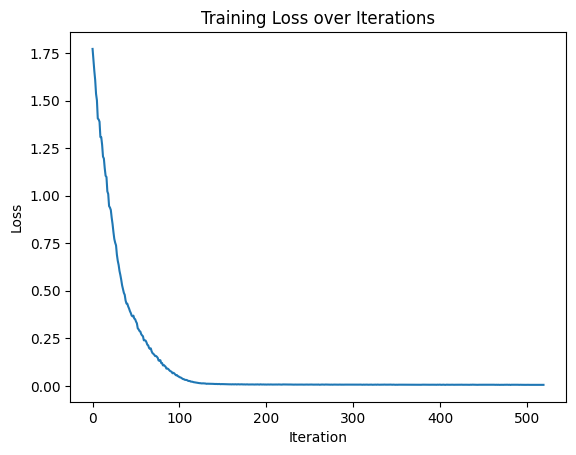

In [ ]:
input_size = n_assets + 1
hidden_sizes = [32, 32, 32]
output_size = 1
activation = nn.Mish()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

nn_trainer = GeneralTrainer(model_config, market_params, put_payoff, seed=42)
nn_trainer.train(batch_size=1000, epochs=10000, tol=1e-6)
nn_trainer.plot_losses()

### Sobolev loss

Iteration 0, Loss: 0.7270749807357788
Iteration 100, Loss: 0.055612869560718536
Iteration 200, Loss: 0.035917818546295166
Iteration 300, Loss: 0.029120074585080147
Iteration 400, Loss: 0.028874129056930542
Iteration 500, Loss: 0.024779444560408592
Iteration 600, Loss: 0.018919941037893295
Iteration 700, Loss: 0.013712423853576183
Iteration 800, Loss: 0.011501293629407883
Iteration 900, Loss: 0.011098013259470463
Iteration 1000, Loss: 0.011580243706703186
Iteration 1100, Loss: 0.010346898809075356
Iteration 1200, Loss: 0.010334013029932976
Iteration 1300, Loss: 0.007514497730880976
Iteration 1400, Loss: 0.008599337190389633
Iteration 1500, Loss: 0.009010720066726208
Iteration 1600, Loss: 0.008338423445820808
Iteration 1700, Loss: 0.006862033158540726
Iteration 1800, Loss: 0.008391090668737888
Iteration 1900, Loss: 0.007435009349137545
Iteration 2000, Loss: 0.006962811574339867
Iteration 2100, Loss: 0.007662434130907059
Iteration 2200, Loss: 0.007241835352033377
Iteration 2300, Loss: 0.0

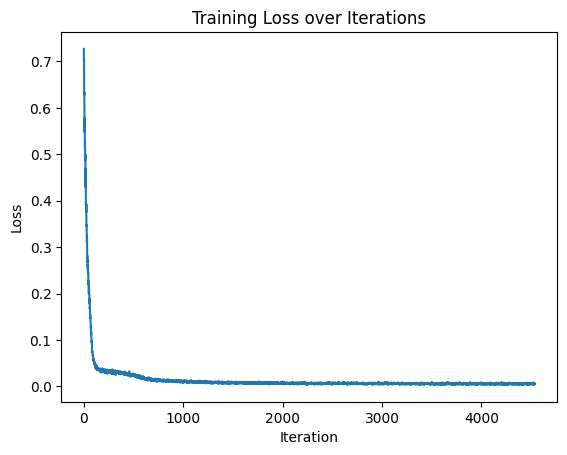

In [19]:
sb_trainer = SobolevTrainer(model_config, market_params, put_payoff, seed=42)
sb_trainer.train(batch_size=1000, epochs=10000, tol=1e-6)
sb_trainer.plot_losses()

### Plot prices

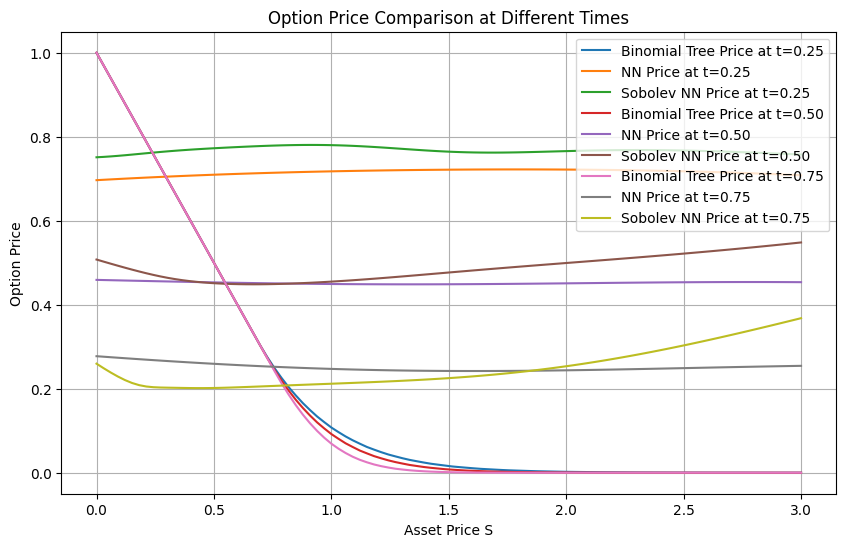

In [26]:
S_range = np.linspace(S_min, S_max, 100)
plt.figure(figsize=(10, 6))
for i, t in enumerate(ts):
    bt_prices = [binomial_tree(S=s, K=K, r=r, sigma=sigma, T=T-t, n=100)[0] for s in S_range]
    nn_price = nn_trainer.predict(S_range, t * np.ones_like(S_range)).detach().numpy()
    sb_price = sb_trainer.predict(S_range, t * np.ones_like(S_range)).detach().numpy()
    
    plt.plot(S_range, bt_prices, label=f'Binomial Tree Price at t={t:.2f}')
    plt.plot(S_range, nn_price, label=f'NN Price at t={t:.2f}')
    plt.plot(S_range, sb_price, label=f'Sobolev NN Price at t={t:.2f}')
    pass
plt.xlabel('Asset Price S')
plt.ylabel('Option Price')
plt.title('Option Price Comparison at Different Times')
plt.legend()
plt.grid()
plt.show()